In [1]:
import pandas as pd

In [2]:
df=pd.read_csv(r"C:\Users\dell\Downloads\archive (3)\Unemployment_Rate_upto_11_2020.csv")

In [3]:
df.head(3)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1    Date                                     267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB


In [5]:
df.isnull().sum()

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Region.1                                    0
longitude                                   0
latitude                                    0
dtype: int64

In [6]:
df = df.dropna()

In [18]:
# df['Date'] = pd.to_datetime(df['Date'])
# df = df.sort_values('Date')
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'])

C:\Users\dell\AppData\Local\Temp\ipykernel_20700\1199385990.py:4: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [19]:
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,2020-06-16 09:15:30.337078528,12.236929,1.396211e+07,41.681573,22.826048,80.532425
min,2020-01-31 00:00:00,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,2020-03-31 00:00:00,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,2020-06-30 00:00:00,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,2020-08-31 00:00:00,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,2020-10-31 00:00:00,75.850000,5.943376e+07,69.690000,33.778200,92.937600
std,NaN,10.803283,1.336632e+07,7.845419,6.270731,5.831738


In [20]:
if 'Region' in df.columns:
    print(df['Region'].unique())

['Andhra Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Meghalaya' 'Odisha' 'Puducherry'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal']


In [24]:
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')

In [21]:
import matplotlib as plt
import matplotlib.pyplot as plt

In [38]:
# plt.figure(figsize=(10,5))
# plt.plot(df['Date'], df['Estimated Labour Participation Rate (%)'])
# plt.title("Estimated Unemployment Rate (%)")
# plt.xlabel("Date")
# plt.ylabel("Rate (%)")
# plt.show()

In [39]:
df['Month'] = df['Date'].dt.to_period('M')
monthly_avg = df.groupby('Month')['Estimated Labour Participation Rate (%)'].mean()

In [40]:
monthly_avg.index = monthly_avg.index.astype(str)

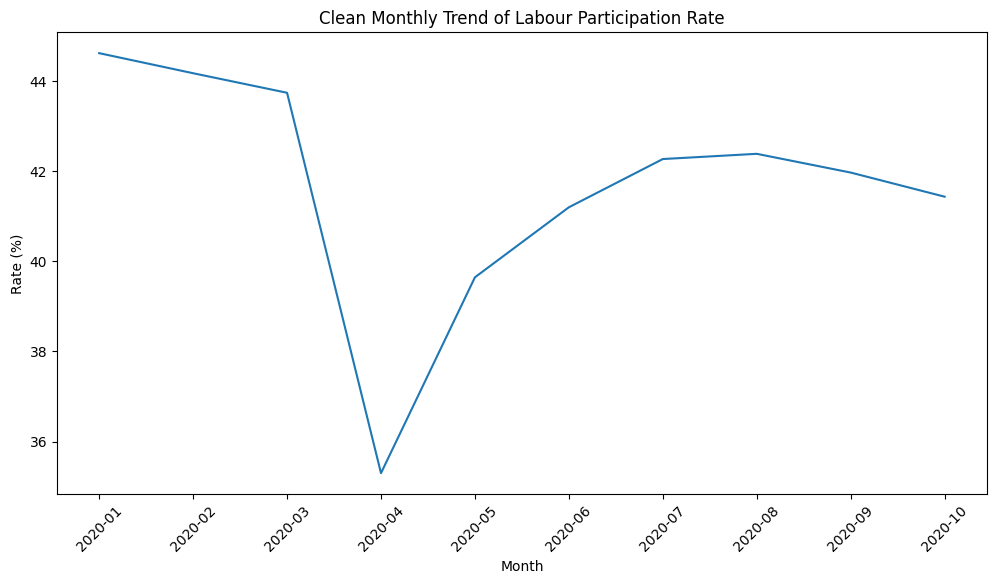

In [43]:
plt.figure(figsize=(12,6))
plt.plot(monthly_avg.index, monthly_avg.values)
plt.xticks(rotation=45)
plt.title("Clean Monthly Trend of Labour Participation Rate")
plt.xlabel("Month")
plt.ylabel("Rate (%)")
plt.show()

In [28]:
before = df[df['Date'] < '2020-03-01']
after = df[df['Date'] >= '2020-03-01']

print("Before COVID Avg:", before['Estimated Unemployment Rate (%)'].mean())
print("During COVID Avg:", after['Estimated Unemployment Rate (%)'].mean())

Before COVID Avg: 9.231346153846154
During COVID Avg: 12.963860465116278


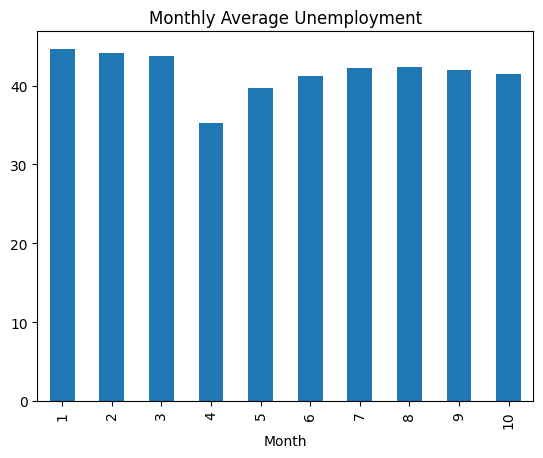

In [31]:
df['Month'] = df['Date'].dt.month

monthly_avg = df.groupby('Month')['Estimated Labour Participation Rate (%)'].mean()

monthly_avg.plot(kind='bar')
plt.title("Monthly Average Unemployment")
plt.show()

In [33]:
import seaborn as sns

In [36]:
# if 'Region' in df.columns:
#     sns.lineplot(data=df, x='Date', y='Estimated Labour Participation Rate (%)', hue='Region')
#     plt.title("Region-wise Unemployment Trend")
#     plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_20700\1338011112.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['Month'] = filtered_df['Date'].dt.to_period('M')


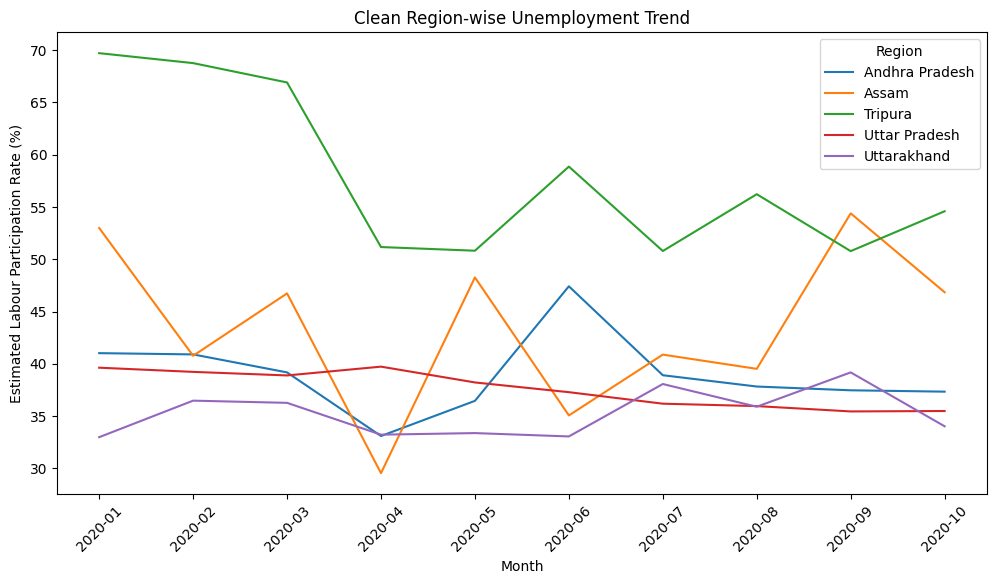

In [37]:
top_regions = df['Region'].value_counts().index[:5]
filtered_df = df[df['Region'].isin(top_regions)]

filtered_df['Month'] = filtered_df['Date'].dt.to_period('M')

monthly_df = filtered_df.groupby(['Month', 'Region'])['Estimated Labour Participation Rate (%)'].mean().reset_index()
monthly_df['Month'] = monthly_df['Month'].astype(str)

plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_df, x='Month', y='Estimated Labour Participation Rate (%)', hue='Region')

plt.xticks(rotation=45)
plt.title("Clean Region-wise Unemployment Trend")
plt.show()